# Сравнение архитектур для длинных последовательностей: Transformer, Mamba, MHLA и ZeroS

- **Transformer (Softmax Attention)**: Вычисляет точную матрицу внимания $O(N^2)$.
- **Mamba (Selective SSM)**: Использует селективные пространства состояний. Параметры зависят от входа, что позволяет модели фильтровать мусор.
- **MHLA (Multi-Head Linear Attention)** [*arXiv:2601.07832*]: Решает проблему *global context collapse*. MHLA вводит механизм **Token-Level Multi-Head Mixing** — внимание вычисляется в разделенных головах, а затем динамически смешивается для каждого токена (query-conditioned selectivity) с помощью обучаемой проекции.
- **ZeroS (Zero-Sum Linear Attention)** [*arXiv:2602.05230*]: Решает проблему *attention dilution*. Разложение Тейлора для softmax $\approx 1/t + \delta_i$ вводит константу $1/t$, которая в длинных текстах создает равномерное смещение. **ZeroS** удаляет этот компонент нулевого порядка, оставляя только zero-mean residuals (допуская отрицательные веса). Дополнительно применяется **Radial-angular decoupling** — сепарация магнитуды и направления через обучаемое гейтирование (gating). Также авторы явно указывают на использование L2-нормализации ключей: $\hat{k}_i = k_i / \|k_i\|$.

In [1]:
!git clone https://github.com/DAGroup-PKU/MHLA.git
!git clone https://github.com/LJC-FVNR/ZeroS.git

Cloning into 'MHLA'...
remote: Enumerating objects: 878, done.
remote: Counting objects: 100% (418/418), done.
remote: Compressing objects: 100% (340/340), done.
remote: Total 878 (delta 85), reused 360 (delta 59), pack-reused 460 (from 1)
Receiving objects: 100% (878/878), 145.07 MiB | 59.68 MiB/s, done.
Resolving deltas: 100% (162/162), done.
Cloning into 'ZeroS'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 32 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 20.26 KiB | 1.01 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
# Устанавливаем базовые библиотеки и официальную Mamba
!pip install -q datasets transformers matplotlib einops tqdm
!pip install -q "mamba-ssm[causal-conv1d]" --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible

In [3]:
import os
import sys
import ast
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time
from einops import rearrange, einsum
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from types import SimpleNamespace
import inspect

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Проверяем доступность Mamba
try:
    from mamba_ssm import Mamba
    print("Официальная Mamba (mamba-ssm) успешно импортирована.")
except ImportError:
    print("mamba-ssm затычка")

Using device: cuda
Официальная Mamba (mamba-ssm) успешно импортирована.


## 1. Подготовка датасета (IMDb)
Загружаем датасет, токенизируем с помощью `bert-base-uncased` и обрезаем/паддим до длины 1024 токена.

In [4]:
dataset = load_dataset("imdb")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 1024
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

print("Tokenizing dataset...")
tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=['text'])

# Для скорости обучения берем подвыборку
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(7000))
test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

def collate_fn(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    attention_mask = torch.tensor([item['attention_mask'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    return input_ids, attention_mask, labels

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

## 2. Примерная реализация моделей по статьям


In [ ]:
from types import SimpleNamespace
import inspect

def load_class_from_repo(repo_path, class_keywords):
    if not os.path.exists(repo_path): return None
    for root, dirs, files in os.walk(repo_path):
        for file in files:
            if file.endswith('.py'):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                        node = ast.parse(content)
                        for n in node.body:
                            if isinstance(n, ast.ClassDef):
                                if any(kw.lower() in n.name.lower() for kw in class_keywords):
                                    spec = importlib.util.spec_from_file_location(n.name, file_path)
                                    mod = importlib.util.module_from_spec(spec)
                                    sys.path.insert(0, root)
                                    spec.loader.exec_module(mod)
                                    print(f"[SUCCESS] Loaded {n.name} directly from {file_path}")
                                    return getattr(mod, n.name)
                except Exception as e:
                    pass
    return None

print("Attempting to load MHLA from repository...")
MHLA_Original = load_class_from_repo('MHLA/mhla_nlp', ['MHLALayer', 'MHLA', 'MultiHeadLinearAttention'])
print("Attempting to load ZeroS from repository...")
ZeroS_Original = load_class_from_repo('ZeroS', ['ZeroSAttention', 'ZeroS'])

# =========================================
# MHLA
# =========================================
class MHLA_Fallback(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)
        self.mix_proj = nn.Linear(d_model, num_heads)
        
    def forward(self, x):
        q, k, v = self.q_proj(x), self.k_proj(x), self.v_proj(x)
        q = rearrange(q, 'b l (h d) -> b h l d', h=self.num_heads)
        k = rearrange(k, 'b l (h d) -> b h l d', h=self.num_heads)
        v = rearrange(v, 'b l (h d) -> b h l d', h=self.num_heads)
        
        q, k = F.elu(q) + 1.0, F.elu(k) + 1.0
        
        kv = einsum(k, v, 'b h l d, b h l m -> b h l d m')
        kv_cumsum = torch.cumsum(kv, dim=2)
        k_cumsum = torch.cumsum(k, dim=2)
        
        num = einsum(q, kv_cumsum, 'b h l d, b h l d m -> b h l m')
        den = einsum(q, k_cumsum, 'b h l d, b h l d -> b h l') + 1e-6
        out = num / den.unsqueeze(-1)
        
        mix_weights = F.softmax(self.mix_proj(x), dim=-1)
        mix_weights = rearrange(mix_weights, 'b l h -> b h l 1')
        
        out = out * mix_weights
        return self.o_proj(rearrange(out, 'b h l d -> b l (h d)'))

# =========================================
# ZeroS
# =========================================
class ZeroS_Fallback(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_heads = config.n_head
        self.d_head = config.n_embd // config.n_head
        self.use_norm = getattr(config, 'use_norm', True)
        self.use_associative = getattr(config, 'use_associative', True)
        
        self.q_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.k_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.v_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.o_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.g_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        
    def forward(self, x):
        B, L, D = x.shape
        q, k, v, g = self.q_proj(x), self.k_proj(x), self.v_proj(x), self.g_proj(x)
        
        q = rearrange(q, 'b l (h d) -> b h l d', h=self.num_heads)
        k = rearrange(k, 'b l (h d) -> b h l d', h=self.num_heads)
        v = rearrange(v, 'b l (h d) -> b h l d', h=self.num_heads)
        
        if self.use_norm:
            k = F.normalize(k, p=2, dim=-1)
            
        if self.use_associative:
            kv = einsum(k, v, 'b h l d, b h l m -> b h l d m')
            kv_cumsum = torch.cumsum(kv, dim=2)
            out = einsum(q, kv_cumsum, 'b h l d, b h l d m -> b h l m')
        else:
            attn = einsum(q, k, 'b h l d, b h m d -> b h l m')
            out = einsum(attn, v, 'b h l m, b h m d -> b h l d')
            
        t = torch.arange(1, L + 1, device=x.device).view(1, 1, L, 1)
        out = out / t
        
        out = rearrange(out, 'b h l d -> b l (h d)')
        return self.o_proj(out * F.silu(g))

MHLA_Layer = MHLA_Original if MHLA_Original is not None else MHLA_Fallback
ZeroS_Layer = ZeroS_Original if ZeroS_Original is not None else ZeroS_Fallback

print(f"Using MHLA: {MHLA_Layer.__name__}")
print(f"Using ZeroS: {ZeroS_Layer.__name__}")

# =========================================
# MAMBA
# =========================================
class MambaLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        
    def forward(self, x):
        return self.mamba(x)

# =========================================
# TRANSFORMER
# =========================================
class TransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
    def forward(self, x, pad_mask):
        L = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(L, device=x.device)
        key_padding_mask = (pad_mask == 0)
        attn_mask = causal_mask.masked_fill(causal_mask == float('-inf'), float('-inf'))
        out, _ = self.attn(x, x, x, is_causal=True, attn_mask=attn_mask, key_padding_mask=key_padding_mask)
        return out

# =========================================
# УМНЫЙ ИНСТАНЦИАТОР
# =========================================
def instantiate_layer(layer_class, d_model, num_heads, max_seq_len=2048):
    sig = inspect.signature(layer_class.__init__)
    params = list(sig.parameters.keys())
    
    if 'config' in params:
        config = SimpleNamespace(
            n_embd=d_model, n_head=num_heads, bias=False, dropout=0.0,
            block_size=max_seq_len, is_causal=True, init_params=True, # <-- ИСПРАВЛЕНО ЗДЕСЬ
            use_norm=True, use_associative=True, init_n_layers=1
        )
        return layer_class(config)
    
    kwargs = {}
    if 'd_model' in sig.parameters: kwargs['d_model'] = d_model
    elif 'dim' in sig.parameters: kwargs['dim'] = d_model
    elif 'hidden_size' in sig.parameters: kwargs['hidden_size'] = d_model
    
    if 'num_heads' in sig.parameters: kwargs['num_heads'] = num_heads
    elif 'n_heads' in sig.parameters: kwargs['n_heads'] = num_heads
    elif 'heads' in sig.parameters: kwargs['heads'] = num_heads
    
    return layer_class(**kwargs)

class Block(nn.Module):
    def __init__(self, d_model, mixer_layer):
        super().__init__()
        self.mixer = mixer_layer
        self.norm1 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        
    def forward(self, x, mask=None):
        if isinstance(self.mixer, TransformerLayer):
            x = x + self.mixer(self.norm1(x), mask)
        else:
            x = x + self.mixer(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class SequenceClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, layer_type, max_seq_len=2048, n_heads=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        
        layers = []
        for _ in range(n_layers):
            if layer_type == 'transformer': layers.append(Block(d_model, TransformerLayer(d_model, n_heads)))
            # Передаем max_seq_len вниз, чтобы ZeroS создал правильный RoPE
            elif layer_type == 'mhla': layers.append(Block(d_model, instantiate_layer(MHLA_Layer, d_model, n_heads, max_seq_len)))
            elif layer_type == 'zeros': layers.append(Block(d_model, instantiate_layer(ZeroS_Layer, d_model, n_heads, max_seq_len)))
            elif layer_type == 'mamba': layers.append(Block(d_model, MambaLayer(d_model)))
                
        self.layers = nn.ModuleList(layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, 2)
        
    def forward(self, x, mask):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.embedding(x) + self.pos_emb(positions)
        for layer in self.layers:
            h = layer(h, mask)
        h = self.norm(h)
        
        mask_expanded = mask.unsqueeze(-1).float()
        sum_embeddings = torch.sum(h * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        return self.classifier(sum_embeddings / sum_mask)

Attempting to load MHLA from repository...
Attempting to load ZeroS from repository...
[SUCCESS] Loaded ZeroSAttention directly from ZeroS/zeros.py
Using MHLA: MHLA_Fallback
Using ZeroS: ZeroSAttention


## 3. Эксперименты: Обучение и Оценка качества
Обучаем модели на задаче классификации IMDb. Мы используем 3 seed для надежности.


Running experiments for TRANSFORMER...


Train TRANSFORMER [Seed 0 | Epoch 1/5]:   0%|          | 0/875 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Train TRANSFORMER [Seed 0 | Epoch 2/5]:   0%|          | 0/875 [00:00<?, ?it/s]

Train TRANSFORMER [Seed 0 | Epoch 3/5]:   0%|          | 0/875 [00:00<?, ?it/s]

...

Train ZEROS [Seed 2 | Epoch 3/5]:   0%|          | 0/875 [00:00<?, ?it/s]

Train ZEROS [Seed 2 | Epoch 4/5]:   0%|          | 0/875 [00:00<?, ?it/s]

Train ZEROS [Seed 2 | Epoch 5/5]:   0%|          | 0/875 [00:00<?, ?it/s]

Eval ZEROS [Seed 2]:   0%|          | 0/63 [00:00<?, ?it/s]

Seed 2 | Accuracy: 0.7580 | Final Loss: 0.3010


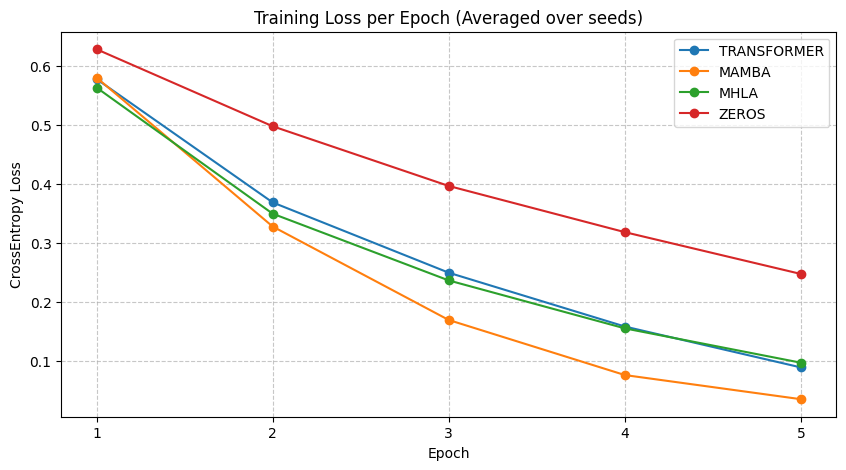

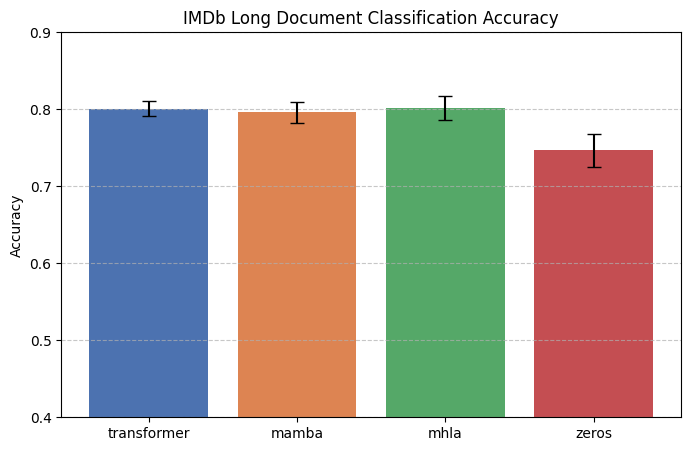

In [6]:
def train_and_eval(model_name, seed, num_epochs=5):
    torch.manual_seed(seed)
    model = SequenceClassifier(vocab_size=tokenizer.vocab_size, d_model=128, n_layers=2, layer_type=model_name, n_heads=4)
    model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    epoch_losses = []
    
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Train {model_name.upper()} [Seed {seed} | Epoch {epoch+1}/{num_epochs}]", leave=False)
        for x, mask, y in train_pbar:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            running_loss += loss.item()
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        eval_pbar = tqdm(test_loader, desc=f"Eval {model_name.upper()} [Seed {seed}]", leave=False)
        for x, mask, y in eval_pbar:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            logits = model(x, mask)
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            
    return correct / total, epoch_losses

models_to_test = ['transformer', 'mamba', 'mhla', 'zeros']
num_seeds = 3
num_epochs = 5

results_acc = {m: [] for m in models_to_test}
results_losses = {m: [] for m in models_to_test} # losses[model] = [ [loss_seed0], [loss_seed1], [loss_seed2] ]

for m_name in models_to_test:
    print(f"\nRunning experiments for {m_name.upper()}...")
    for seed in range(num_seeds):
        acc, losses = train_and_eval(m_name, seed, num_epochs=num_epochs)
        print(f"Seed {seed} | Accuracy: {acc:.4f} | Final Loss: {losses[-1]:.4f}")
        results_acc[m_name].append(acc)
        results_losses[m_name].append(losses)
        

plt.figure(figsize=(10, 5))
epochs_axis = range(1, num_epochs + 1)

for m_name in models_to_test:
    mean_losses = np.mean(results_losses[m_name], axis=0)
    plt.plot(epochs_axis, mean_losses, marker='o', label=m_name.upper())

plt.title('Training Loss per Epoch (Averaged over seeds)')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

mean_accs = {m: np.mean(accs) for m, accs in results_acc.items()}
std_accs = {m: np.std(accs) for m, accs in results_acc.items()}

plt.figure(figsize=(8, 5))
bars = plt.bar(mean_accs.keys(), mean_accs.values(), yerr=std_accs.values(), capsize=5, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('IMDb Long Document Classification Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.4, 0.9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Бенчмарки: Память и Пропускная способность (Efficiency)
Проверяем масштабируемость моделей при увеличении длины контекста. Для чистоты эксперимента бенчмарк использует dummy-данные, чтобы исключить накладные расходы токенизатора.

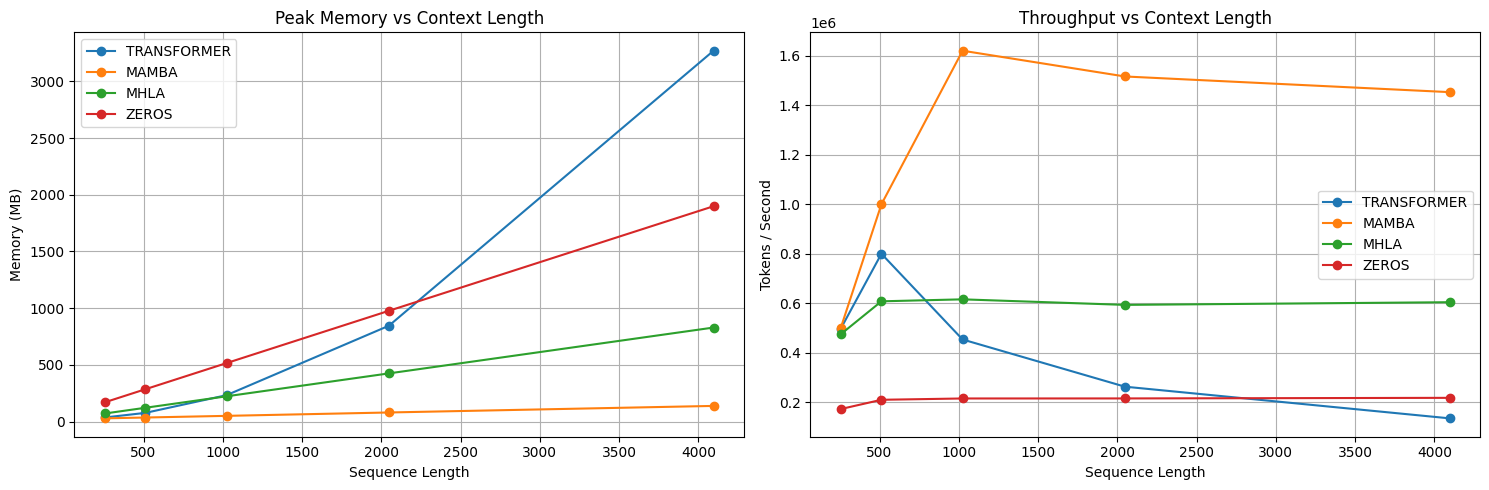

In [7]:
def benchmark_efficiency(model_name, seq_lengths, batch_size=4):
    # ВАЖНО: Устанавливаем max_seq_len равным максимальной тестируемой длине
    max_len = max(seq_lengths)
    model = SequenceClassifier(vocab_size=1000, d_model=128, n_layers=2, layer_type=model_name, max_seq_len=max_len)
    model.to(device)
    model.eval()
    
    memory_allocated = []
    throughputs = []
    
    for length in seq_lengths:
        x = torch.randint(1, 1000, (batch_size, length), device=device)
        mask = torch.ones((batch_size, length), device=device)
        
        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model(x, mask)
                
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            
        start = time.time()
        iters = 5
        for _ in range(iters):
            with torch.no_grad(): _ = model(x, mask)
                
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            mem = torch.cuda.max_memory_allocated() / (1024 ** 2) # MB
        else:
            mem = 0.0
            
        end = time.time()
        throughput = (batch_size * length * iters) / (end - start)
        
        throughputs.append(throughput)
        memory_allocated.append(mem)
        
    return memory_allocated, throughputs

seq_lengths = [256, 512, 1024, 2048, 4096]
results_mem = {}
results_thr = {}

for m_name in ['transformer', 'mamba', 'mhla', 'zeros']:
    mem, thr = benchmark_efficiency(m_name, seq_lengths, batch_size=4)
    results_mem[m_name] = mem
    results_thr[m_name] = thr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Memory Plot
for m_name, mem in results_mem.items():
    ax1.plot(seq_lengths, mem, marker='o', label=m_name.upper())
ax1.set_title('Peak Memory vs Context Length')
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Memory (MB)')
ax1.legend()
ax1.grid(True)

# Throughput Plot
for m_name, thr in results_thr.items():
    ax2.plot(seq_lengths, thr, marker='o', label=m_name.upper())
ax2.set_title('Throughput vs Context Length')
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Tokens / Second')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Выводы:*
*   **MHLA и базовая Transformer - лучше всех.** Они разделили первое место (~80% точности). Фишка MHLA реально работает: они сделали линейное внимание, которое не "тупеет" на длинных текстах и выдает качество тяжелого Трансформера.
*   **Mamba - хороша.** Уступила незначительно (79.6%), но график лосса показывает, что она учится быстрее всех. Модель быстро схватывает датасет.
*   **ZeroS оказался хуже всех.** Точность всего ~74.7%, лосс выше чем у остальных. Видимо, для классификации текстов эта архитектура просто так не даст хорошие результаты выше остальных.

**2. Кто прожорливее (Память и Скорость)**
*   **Transformer ожидаемо самый требовательный".** Как только длина текста перевалила за 2000 токенов, память значительно выроссла (классическая $O(N^2)$ проблема), а скорость обработки замедлилась сильно.
*   **Mamba - лучше всех.** За счет их официального С++ ядра она почти не ест память и переваривает по 1.5 млн токенов в секунду независимо от длины текста.
*   **MHLA и ZeroS - стабильные и экономные.** Память у них растет ровно (линейно, а не квадратично), GPU не задыхается. Скорость от длины текста тоже не проседает (правда ZeroS медленнее).

**Главный итог:**
Если нужно делать реальный проект с длинными текстами (документами, книгами) - можно брать **Mamba**, эффективна по скорости и экономии памяти. 
Если требуется использовать именно архитектуру Transformer, то **MHLA** - неплохая замена базовому вниманию: мы сохраняем высокое качество, но спасаем видеокарту от нехватки памяти.
А вот ZeroS в данной задаче показал себя не очень. Возможно стоит пробовать архитектуру для других, более специфичных данных (например, временных рядов), либо более тонко настроить архитектуру.